In [ ]:
# mount your google drive to load files directly from there
from google.colab import drive
drive.mount('/content/drive')  # This connects Google Colab to your Drive so it can read your data files.

Mounted at /content/drive


In [ ]:
# if you want to import Python files, add the correct Google Drive directory to your Pythonpath
import sys
sys.path.append('/content/drive/My Drive/work/teaching/2025 Advanced Deep Learning/')

In [ ]:
# Download the data from huggingface (https://huggingface.co/datasets/simbaswe/galah4/tree/main)
# and upload it to your google drive. Then, specify this directory here
DATA_PATH = '/content/drive/My Drive/work/Advanced Deep Learning/data/galah4/'

In [ ]:
# import the stuff you need. Pytorch is already installed on Google colab
import os            # to handle file paths
import time          # imported to track training duration
import sys
import torch         # the core PyTorch library
import torch.nn as nn        # neural network building blocks (layers, activations, loss functions
import torch.optim as optim      # optimizers (like Adam, SGD) that update the weights
from torch.utils.data import DataLoader, TensorDataset, random_split    # DataLoader:    feeds data in batches during training
                                                                  # TensorDataset: wraps your numpy arrays into a PyTorch-compatible dataset
                                                                  # random_split:  splits data into train/validation/test sets
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary         # prints a nice model architecture table
import helper                            # your instructor's helper file

In [ ]:
spectra = np.load(f"{DATA_PATH}/spectra.npy")  # shape: (n_stars, spectrum_length) — each row is one star
spectra_length = spectra.shape[1]

# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{DATA_PATH}/labels.npy")    # shape: (n_stars, 8) originally

# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]          #keep only columns for t_eff, log_g, fe_h (drop SNR)
n_labels = labels.shape[1]

In [ ]:
# normalize the spectra
spectra = np.log(np.maximum(spectra, 0.2))      # np.maximum(spectra, 0.2) clamps any value below 0.2 up to 0.2 (avoids log of zero or negative).
                                                # then np.log(...) compresses the range. Neural networks train much better on data that isn't wildly scaled.

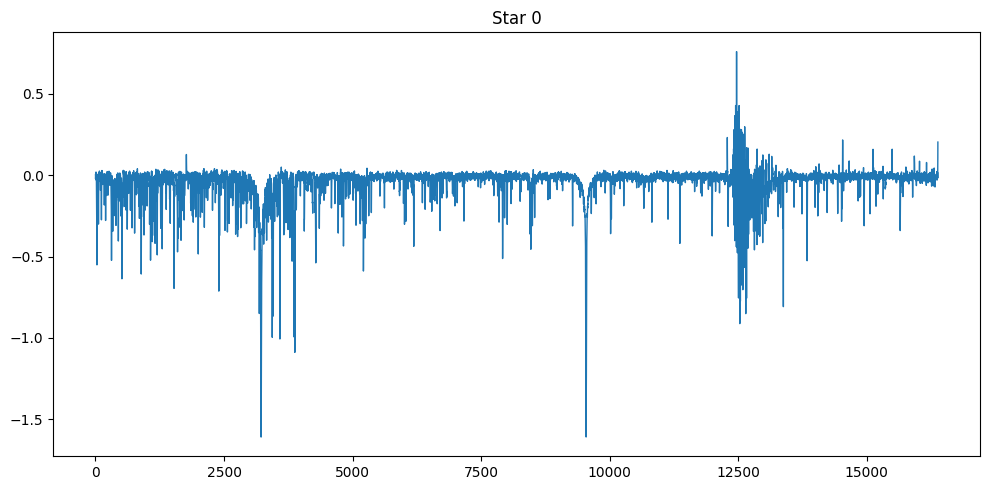

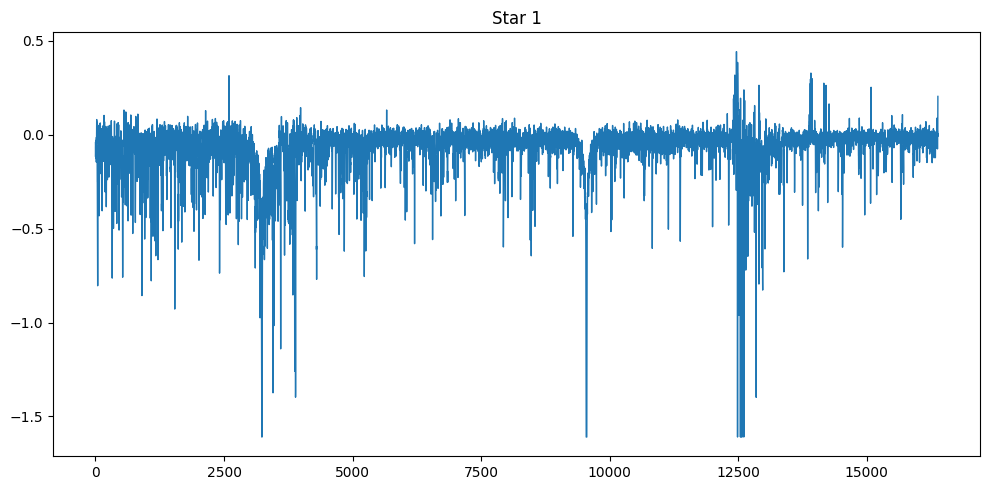

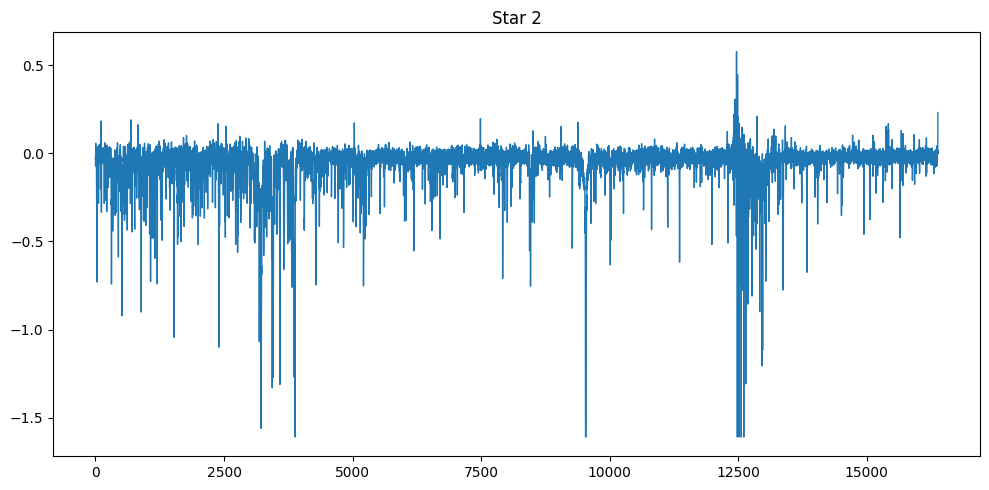

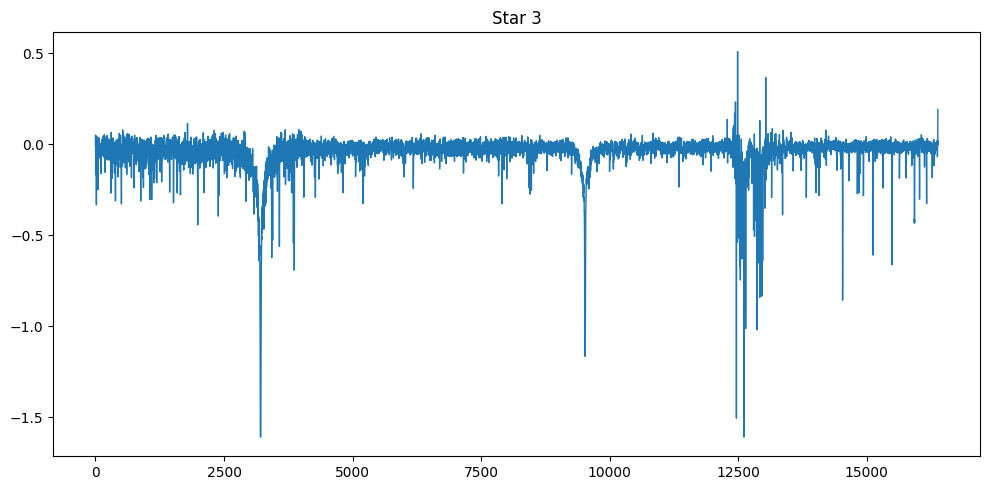

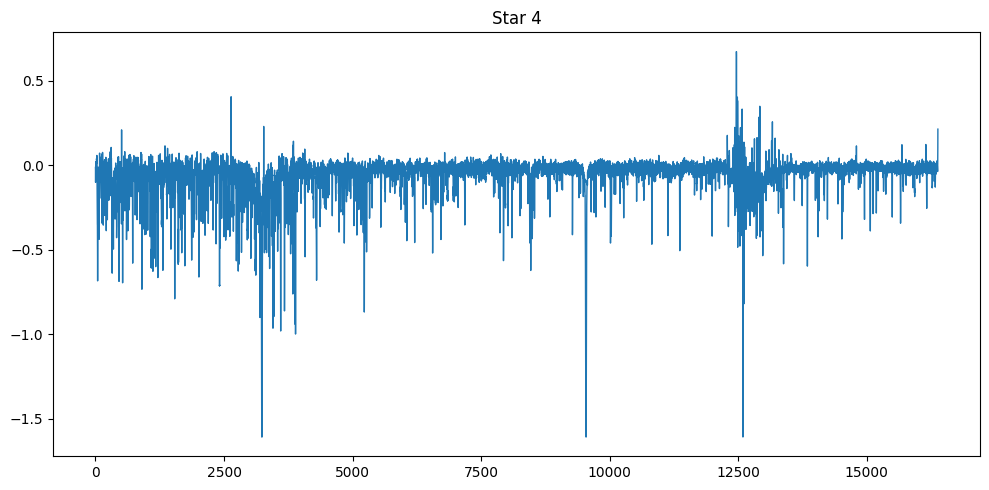

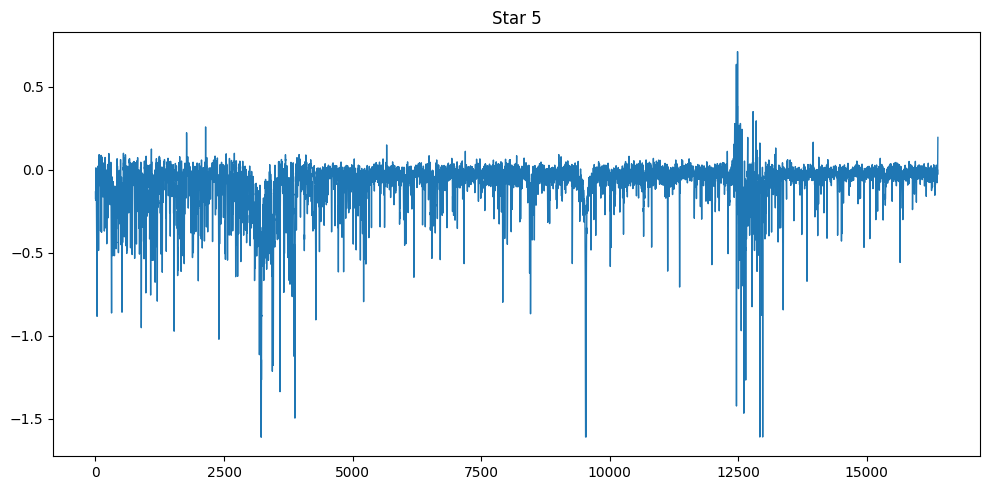

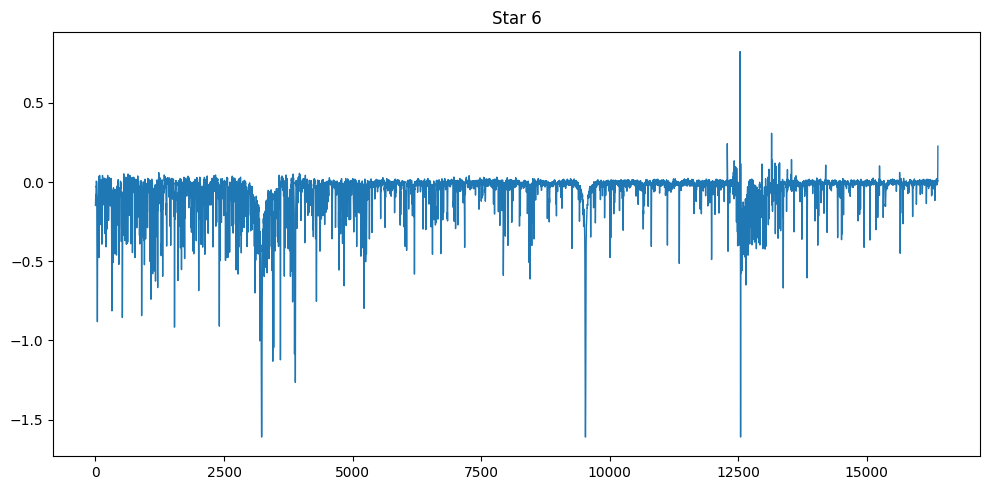

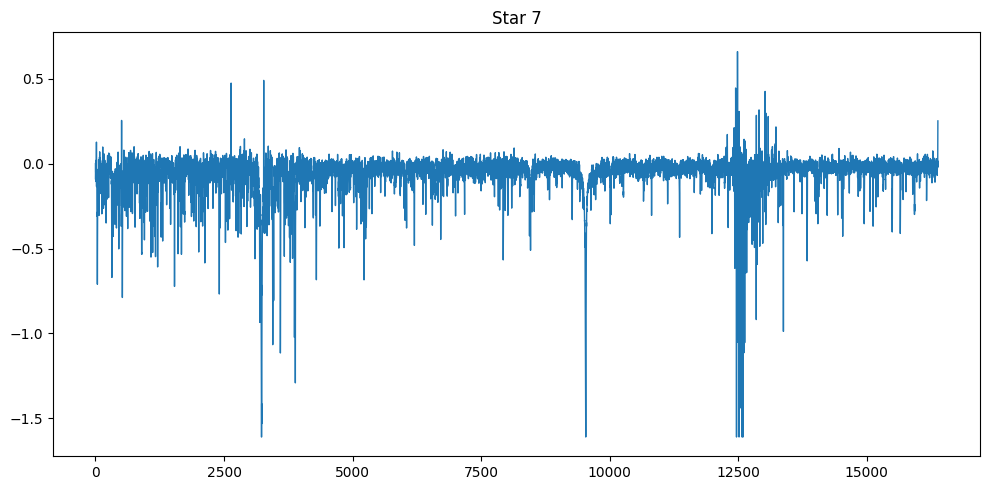

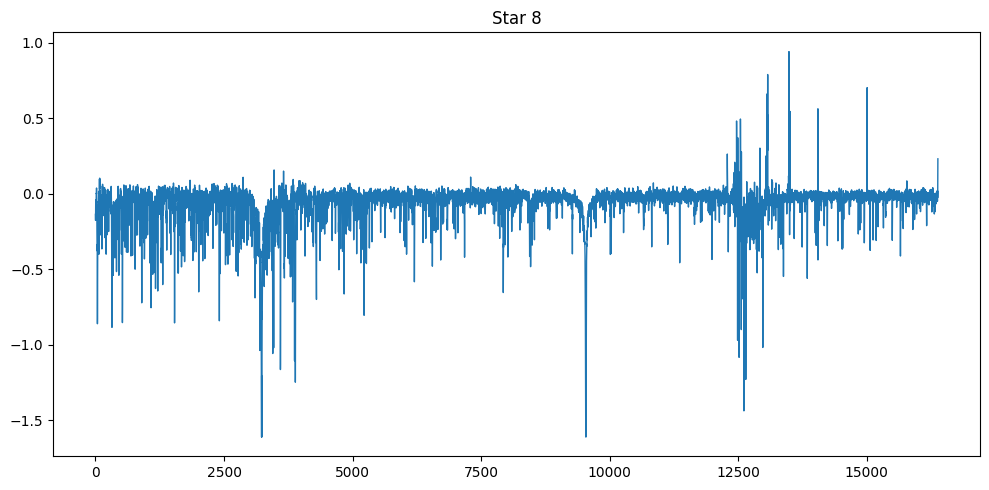

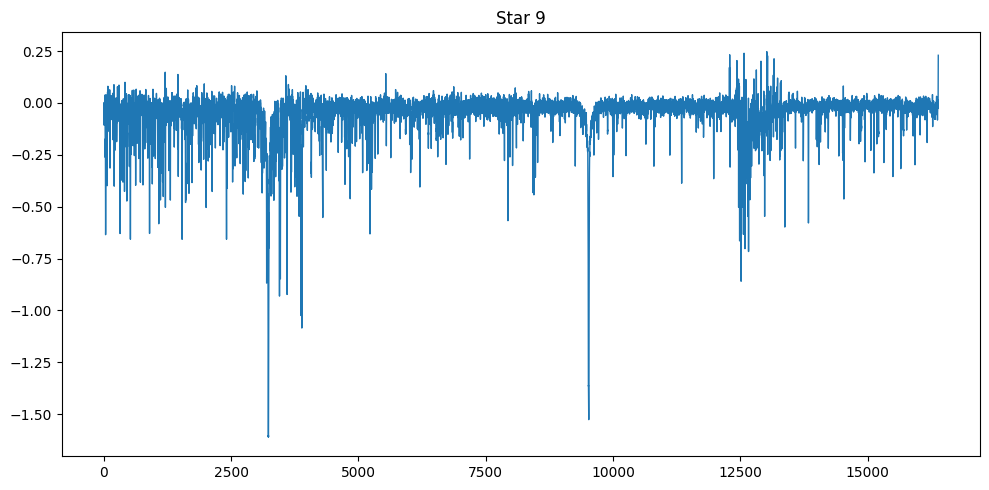

In [ ]:
%matplotlib inline
# plot a few spectra
for i in range(10):
  fig, ax = plt.subplots(1, 1, figsize=(10, 5))
  ax.plot(spectra[i], lw=1)
  ax.set_title(f"Star {i}")
  plt.tight_layout()

## Implementation of a Standard CNN to Predict the Three Labels

### Step 1: Converting NumPy Arrays to PyTorch Tensors

In [ ]:
# Convert numpy arrays to PyTorch tensors
# PyTorch cannot work with numpy arrays directly, so we convert them
X = torch.tensor(spectra, dtype=torch.float32)  # shape: (n_stars, spectrum_length)
y = torch.tensor(labels,  dtype=torch.float32)  # shape: (n_stars, 3)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([8914, 16384])
y shape: torch.Size([8914, 3])


### Step 2: Creating a TensorDataset and Splitting into Train/Validation/Test sets

In [ ]:
# Wrap X and y into a TensorDataset
# TensorDataset simply pairs each spectrum with its corresponding labels
# so that X[i] and y[i] always stay together
dataset = TensorDataset(X, y)

# Split into train (80%), validation (10%), test (10%)
total = len(dataset)                          # 8914 stars total
train_size = int(0.8 * total)                 # 7131 stars for training
val_size   = int(0.1 * total)                 # 891 stars for validation
test_size  = total - train_size - val_size    # remaining stars for test


# random_split shuffles the data randomly and divides it into three groups: Train, Validation and Test.
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

print(f"Training:   {len(train_set)} stars")
print(f"Validation: {len(val_set)} stars")
print(f"Test:       {len(test_set)} stars")

Training:   7131 stars
Validation: 891 stars
Test:       892 stars


### Step 3: Creating DataLoaders

In [ ]:
# Create DataLoaders for each set
# A DataLoader feeds data to the model in small batches during training

'''A DataLoader chops/divides the data into batches of 32 stars and feeds them one batch at a time. Reason for choping data is that if we fee
 all 7131 training stars into the network at once than it would require huge amounts of memory.'''

# #shuffle=True for training: randomly shuffles the stars each epoch so the model doesn't memorize the order.
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)   # batch_size=32: 32 stars per batch.
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)  # shuffle=False for validation and test: no need to shuffle these since we're just measuring performance, not learning.
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")       # 7131 ÷ 32 = 222.8 approximatley 223

Number of training batches: 223


### Step 4: Creating the CNN Model

In [ ]:
class VanillaCNN(nn.Module):
    def __init__(self, input_length, n_labels):
        super(VanillaCNN, self).__init__()

        self.features = nn.Sequential(
            #First convolutional block
            # in_channels=1: the spectrum is 1D, one channel (like grayscale vs RGB)
            # out_channels=16: learns 16 different pattern detectors simultaneously
            # padding=1: adds one zero at each edge to preserve the output length

            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),                   # ReLU is activation Function, introduces non-linearity which allows the network to learn complex patterns.
            nn.MaxPool1d(kernel_size=2), # This cuts the length of the signal in half by taking the maximum of every pair of values

            # Second convolutional block
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            # Third convolutional block
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )


        # Sequential is just a container that runs layers one after another in order.
        # After the conv layers, the signal is flattened into a single long vector and passed through fully connected layers:
        self.regressor = nn.Sequential(
            nn.Linear(64 * (input_length // 8), 256), # First Linear: takes the flattened conv output → compresses to 256 values
            nn.ReLU(),                                # ReLU: non-linearity
            nn.Linear(256, n_labels)                  # Second Linear: 256 values → 3 final predictions (t_eff, log_g, fe_h)
        )

    #This defines the path data travels through the network. PyTorch calls forward() automatically.
    def forward(self, x):
        x = x.unsqueeze(1)        # add channel dimension
        x = self.features(x)      # pass through conv layers
        x = x.flatten(1)          # flatten for linear layers
        x = self.regressor(x)     # predict the 3 labels
        return x

# Create the model
model = VanillaCNN(input_length=spectra_length, n_labels=n_labels)
print(model)





VanillaCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (regressor): Sequential(
    (0): Linear(in_features=131072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=3, bias=True)
  )
)


### Model Architecture Summary

**Features (Conv layers):**

| Layer | Pattern Detectors | Spectrum Length |
|-------|------------------|-----------------|
| Conv1d(1→16, kernel=3) + ReLU + MaxPool | 16 | 16384 → 8192 |
| Conv1d(16→32, kernel=3) + ReLU + MaxPool | 32 | 8192 → 4096 |
| Conv1d(32→64, kernel=3) + ReLU + MaxPool | 64 | 4096 → 2048 |

**Regressor (Linear layers):**

| Layer | Details |
|-------|---------|
| Flatten | 64 × 2048 = 131072 values |
| Linear(131072 → 256) + ReLU | compresses to 256 values |
| Linear(256 → 3) | final output: t_eff, log_g, fe_h |

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 33,563,299


### Step 5: Training the Model

In [ ]:
# Set device - use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  #  This checks if a GPU is available (in Colab it is, since we selected T4 GPU).
print(f"Training on: {device}")                                        # If it is available, use it. If not, fall back to CPU.

# Move model to device
model = model.to(device)          # Moving the model to the device means all its 33 million weights live on the GPU now.

# Loss function and optimizer
criterion = nn.MSELoss()          # MSE stands for Mean Squared Error. It measures how wrong the model's predictions are.
optimizer = optim.Adam(model.parameters(), lr=0.001) #  Adam is the algorithm that updates the 33 million weights after each batch.
                                                    # lr=0.001 is the learning rate. It tells how big a step to take when adjusting weights.
                                                    # if lr is too large,  the model overshoots,
                                                    # if it is too small, it learns painfully slowly. 0.001 is a safe default.

# Training loop
n_epochs = 20              # Repeat everything 20 times (20 epochs)
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    # --- Training phase ---
    model.train()                           # switches to training mode (some layers behave differently in train vs eval mode)
    running_loss = 0.0                      # accumulates loss over all batches in this epoch
    for X_batch, y_batch in train_loader:   # this grabs one batch of 32 stars at a time from the DataLoader.
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()          # clear old gradients(PyTorch accumulates gradients by default, so must clear them at the start of each batch)
        predictions = model(X_batch)   # forward pass: feeds the batch through the network and gets predictions.
        loss = criterion(predictions, y_batch)  # Compares predictions to the true labels and computes the MSE loss
        loss.backward()                # backpropagation
        optimizer.step()               # update weights

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader) # # average loss per batch for this epoch
    train_losses.append(train_loss)

    # --- Validation phase ---
    model.eval()                  # switches to evaluation mode; no learning, just measuring performance
    val_loss = 0.0
    with torch.no_grad():          # torch.no_grad() tells PyTorch not to track gradients, we're just measuring performance, not learning
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            val_loss += criterion(predictions, y_batch).item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)    # save the loss after each epoch

    print(f"Epoch {epoch+1}/{n_epochs}  |  Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}")

Training on: cuda
Epoch 1/20  |  Train Loss: 754582.1312  |  Val Loss: 71644.1885
Epoch 2/20  |  Train Loss: 72865.0014  |  Val Loss: 62163.8930
Epoch 3/20  |  Train Loss: 56139.1299  |  Val Loss: 36425.0152
Epoch 4/20  |  Train Loss: 30689.6547  |  Val Loss: 25499.8084
Epoch 5/20  |  Train Loss: 21602.3208  |  Val Loss: 19501.9645
Epoch 6/20  |  Train Loss: 11921.7996  |  Val Loss: 8643.0226
Epoch 7/20  |  Train Loss: 7434.4355  |  Val Loss: 7206.2900
Epoch 8/20  |  Train Loss: 5513.4182  |  Val Loss: 4967.8004
Epoch 9/20  |  Train Loss: 4745.3027  |  Val Loss: 5477.8647
Epoch 10/20  |  Train Loss: 4218.8221  |  Val Loss: 3845.6930
Epoch 11/20  |  Train Loss: 3915.2103  |  Val Loss: 3470.8381
Epoch 12/20  |  Train Loss: 3374.3911  |  Val Loss: 3360.7544
Epoch 13/20  |  Train Loss: 3516.8836  |  Val Loss: 3418.7693
Epoch 14/20  |  Train Loss: 3280.8003  |  Val Loss: 3783.6275
Epoch 15/20  |  Train Loss: 2991.0685  |  Val Loss: 3117.0112
Epoch 16/20  |  Train Loss: 3195.9466  |  Val Los

### Step 6: Visualizing Training Performance

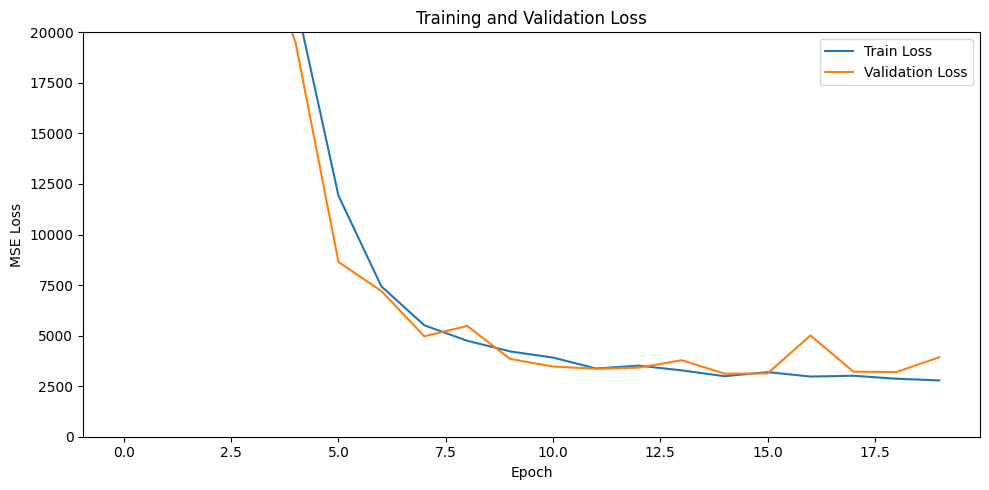

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.ylim(0, 20000)   # zoom in on y-axis
plt.tight_layout()
plt.show()

### Step 7: Evaluating on the Test Set

In [ ]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        predictions = model(X_batch)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(y_batch.numpy())

all_predictions = np.concatenate(all_predictions, axis=0)
all_targets     = np.concatenate(all_targets,     axis=0)

# Print MSE for each label separately
for i, name in enumerate(labelNames):
    mse = np.mean((all_predictions[:, i] - all_targets[:, i])**2)
    print(f"{name}: MSE = {mse:.2f}")

t_eff: MSE = 10966.71
log_g: MSE = 52.83
fe_h: MSE = 9.21


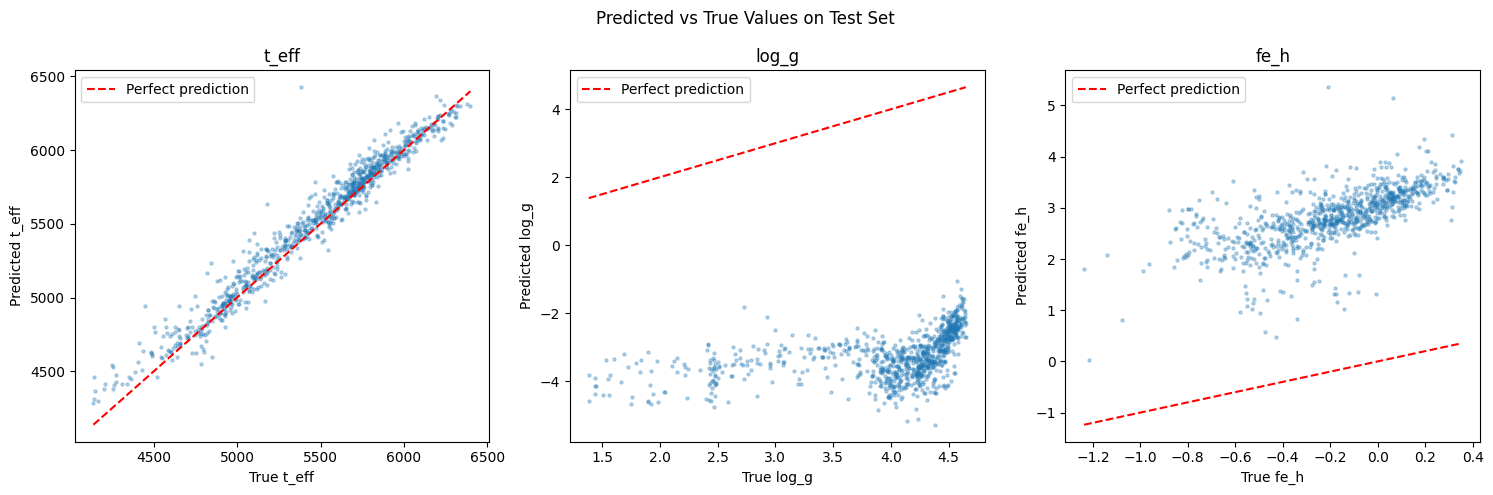

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, name in enumerate(labelNames):
    axes[i].scatter(all_targets[:, i], all_predictions[:, i],
                    alpha=0.3, s=5)
    # perfect prediction line
    min_val = all_targets[:, i].min()
    max_val = all_targets[:, i].max()
    axes[i].plot([min_val, max_val], [min_val, max_val],
                 'r--', label='Perfect prediction')
    axes[i].set_xlabel(f'True {name}')
    axes[i].set_ylabel(f'Predicted {name}')
    axes[i].set_title(f'{name}')
    axes[i].legend()

plt.suptitle('Predicted vs True Values on Test Set')
plt.tight_layout()
plt.show()

# Discussion on Results:
## 1. t_eff (left):
The points closely follow the red dashed line. This shows that model learned to predict stellar temperature quite well. There's some scatter but the overall trend is strong and diagonal which means predictions align well with the true values.

## 2. log_g (middle):
The points form a horizontal cluster instead of following the diagonal line. This means the model is predicting almost the same value (~2) for all stars, regardless of their true log_g. It essentially learned the average rather than the underlying relationship and gave up. This is a sign the model struggled to extract log_g information from the spectra.

## 3. fe_h (right):
A similar pattern appears. The points form a vertical blob rather than following the diagonal. This shows that the model is not capturing the true variation in iron abundance.

### Overall:
The model performs well on t_eff but struggles with log_g and fe_h.
This suggests the spectra contain clearer information about stellar
temperature than about surface gravity or iron abundance, or that
the model needs improvement to extract those subtler patterns.